# Notebook 05 — Pre-Model Figures & Statistics

Distribution, spatial, temporal, and weather/event analysis of the Processed table
(`data/processed/pickups_zone_hour.parquet`, built in notebook `04`). This is a
focused, curated set of figures and statistics — it does **not** carry forward the
broader exploration the old `03_eda.ipynb` / `04_geospatial_pickup_heatmaps.ipynb`
notebooks contained.

Covers distribution/spatial concentration, temporal patterns, and weather/event
relationships, with Figures 2–4.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR
from src.geospatial import build_zone_choropleth_data, load_processed_zone_hour, load_taxi_zones

processed_df = load_processed_zone_hour()
zones = load_taxi_zones()
print(f"Processed rows: {len(processed_df):,}")

2026-08-31 22:07:42.773 | INFO     | src.config:<module>:26 - PROJ_ROOT path is: /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final


Processed rows: 11,134,368


## 2. Section 3.1 — distribution and spatial concentration

Summary statistics of `pickup_count`'s distribution across all zone-hours: central
tendency, zero-rate, and the shape of the long right tail.

In [2]:
combined = processed_df.groupby(
    ["pu_location_id", "pickup_hour"], as_index=False
)["pickup_count"].sum()

median = combined["pickup_count"].median()
pct_zero = 100 * (combined["pickup_count"] == 0).mean()
mean = combined["pickup_count"].mean()
p99 = combined["pickup_count"].quantile(0.99)
max_pickups = combined["pickup_count"].max()

print("Section 3.1 -- distribution (Yellow+Green combined, per zone-hour)")
print(f"  Median:                {median:.0f} pickup")
print(f"  Exactly zero:          {pct_zero:.1f}%")
print(f"  Mean:                  {mean:.1f}")
print(f"  P99 (busiest 1% exceed): {p99:.0f} pickups")
print(f"  Citywide maximum:      {max_pickups:,.0f}")

Section 3.1 -- distribution (Yellow+Green combined, per zone-hour)
  Median:                1 pickup
  Exactly zero:          45.9%
  Mean:                  18.5
  P99 (busiest 1% exceed): 275 pickups
  Citywide maximum:      1,085


How mean demand in Manhattan and the JFK/LaGuardia zones compares to the rest of
the city's outer-borough zones.

In [3]:
mean_demand = combined.groupby("pu_location_id", as_index=False)["pickup_count"].mean()
mean_demand = mean_demand.rename(columns={"pickup_count": "mean_pickup_count"})

gdf = build_zone_choropleth_data(mean_demand, zones, "mean_pickup_count")

AIRPORT_ZONE_IDS = {132, 138}  # JFK, LaGuardia
manhattan_or_airport = (gdf["borough"] == "Manhattan") | (gdf["LocationID"].isin(AIRPORT_ZONE_IDS))

core_mean = gdf.loc[manhattan_or_airport, "mean_pickup_count"].mean()
outer_mean = gdf.loc[~manhattan_or_airport, "mean_pickup_count"].mean()

print("Section 3.1 -- spatial concentration")
print(f"  Manhattan + JFK/LaGuardia mean demand: {core_mean:.2f} pickups/hour")
print(f"  Outer-borough mean demand:             {outer_mean:.2f} pickups/hour")
print(f"  Ratio:                                 {core_mean / outer_mean:.2f}x")

Section 3.1 -- spatial concentration
  Manhattan + JFK/LaGuardia mean demand: 64.65 pickups/hour
  Outer-borough mean demand:             1.47 pickups/hour
  Ratio:                                 43.94x


### Figure 2 — distribution and spatial concentration

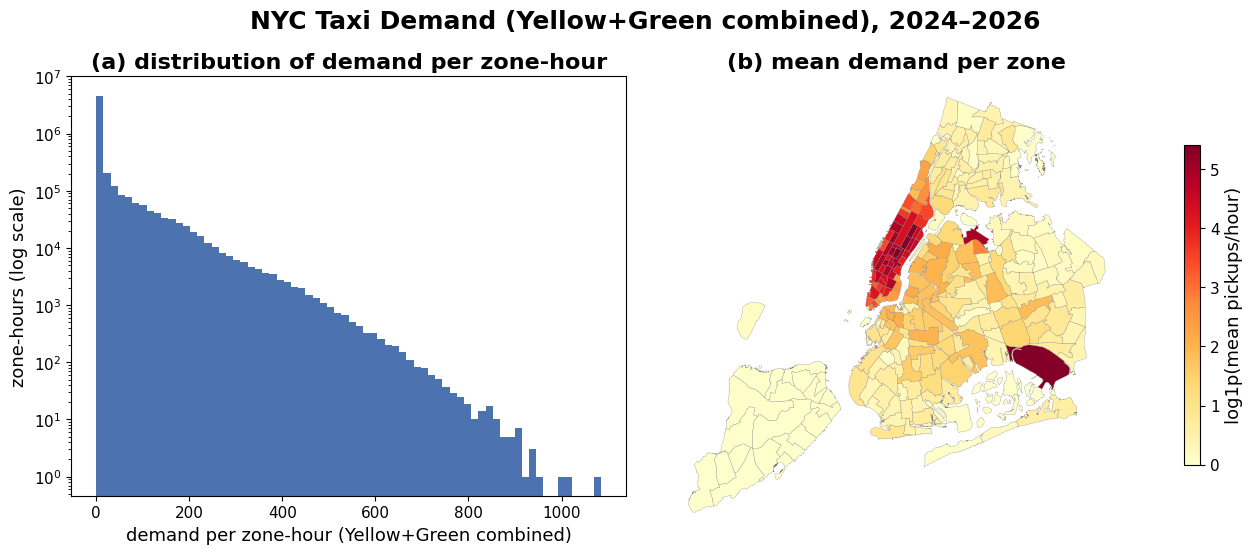

Saved /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final/reports/figures/distribution_and_map_combined.png


In [4]:
minx, miny, maxx, maxy = zones.total_bounds
map_aspect = (maxy - miny) / (maxx - minx)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
ax.hist(combined["pickup_count"], bins=70, color="#4c72b0")
ax.set_yscale("log")
ax.set_title("(a) distribution of demand per zone-hour", fontsize=16, fontweight="bold")
ax.set_xlabel("demand per zone-hour (Yellow+Green combined)", fontsize=13)
ax.set_ylabel("zone-hours (log scale)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
ax.set_box_aspect(map_aspect)
ax.set_anchor("N")

gdf["log1p_mean_pickup_count"] = np.log1p(gdf["mean_pickup_count"])
ax = axes[1]
gdf.plot(
    column="log1p_mean_pickup_count", cmap="YlOrRd", linewidth=0.2, edgecolor="grey",
    legend=True, vmin=0, vmax=gdf["log1p_mean_pickup_count"].max(),
    legend_kwds={"label": "log1p(mean pickups/hour)", "shrink": 0.7}, ax=ax,
)
# legend_kwds has no fontsize passthrough for the colorbar label -- set it directly on
# the colorbar's own axis (the one just appended to the figure) to match the
# fontsize=13/labelsize=11 convention used for axis labels elsewhere in the report.
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("log1p(mean pickups/hour)", fontsize=13)
cbar_ax.tick_params(labelsize=11)
ax.set_title("(b) mean demand per zone", fontsize=16, fontweight="bold")
ax.set_axis_off()
ax.set_anchor("N")

fig.suptitle(
    "NYC Taxi Demand (Yellow+Green combined), 2024–2026", y=0.98, fontsize=18, fontweight="bold"
)
fig.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIGURES_DIR / "distribution_and_map_combined.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## 3. Section 3.2 — temporal patterns

Demand by day of week and hour of day: the weekly swing, the evening-commute peak, and
the weekend-driven midnight pattern.

In [5]:
combined_dow = processed_df.groupby(
    ["pu_location_id", "pickup_hour", "day_of_week"], as_index=False
)["pickup_count"].sum()
combined_dow["hour_of_day"] = combined_dow["pickup_hour"].dt.hour

by_day_hour = combined_dow.groupby(["day_of_week", "hour_of_day"])["pickup_count"].mean().reset_index()
by_day_mean = by_day_hour.groupby("day_of_week")["pickup_count"].mean()

DOW_LABELS = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
monday, thursday = by_day_mean[2], by_day_mean[5]
swing_pct = 100 * (thursday - monday) / monday

print("Section 3.2 -- day-of-week swing")
print(f"  Monday:   {monday:.1f} mean pickups/hour")
print(f"  Thursday: {thursday:.1f} mean pickups/hour")
print(f"  Swing:    {swing_pct:.0f}%")

Section 3.2 -- day-of-week swing
  Monday:   15.8 mean pickups/hour
  Thursday: 20.1 mean pickups/hour
  Swing:    28%


In [6]:
weekday_days = [2, 3, 4, 5, 6]
weekend_days = [1, 7]

weekday_curve = by_day_hour[by_day_hour["day_of_week"].isin(weekday_days)].groupby("hour_of_day")["pickup_count"].mean()
weekend_curve = by_day_hour[by_day_hour["day_of_week"].isin(weekend_days)].groupby("hour_of_day")["pickup_count"].mean()

print("Section 3.2 -- evening commute peak (hour-averaged curve, weekday vs weekend)")
print(f"  Weekday peak: {weekday_curve.max():.1f} mean pickups/hour at hour {weekday_curve.idxmax()}")
print(f"  Weekend peak: {weekend_curve.max():.1f} mean pickups/hour at hour {weekend_curve.idxmax()}")

midnight = by_day_hour[by_day_hour["hour_of_day"] == 0]
weekday_midnight = midnight[midnight["day_of_week"].isin(weekday_days)]["pickup_count"].mean()
weekend_midnight = midnight[midnight["day_of_week"].isin(weekend_days)]["pickup_count"].mean()

print("\nSection 3.2 -- midnight demand, weekend vs weekday")
print(f"  Weekday midnight: {weekday_midnight:.1f} mean pickups/hour")
print(f"  Weekend midnight: {weekend_midnight:.1f} mean pickups/hour")
print(f"  Ratio:            {weekend_midnight / weekday_midnight:.1f}x")

Section 3.2 -- evening commute peak (hour-averaged curve, weekday vs weekend)
  Weekday peak: 31.5 mean pickups/hour at hour 18
  Weekend peak: 28.1 mean pickups/hour at hour 18

Section 3.2 -- midnight demand, weekend vs weekday
  Weekday midnight: 8.6 mean pickups/hour
  Weekend midnight: 25.1 mean pickups/hour
  Ratio:            2.9x


### Figure 3 — mean demand by hour of day, per day of week

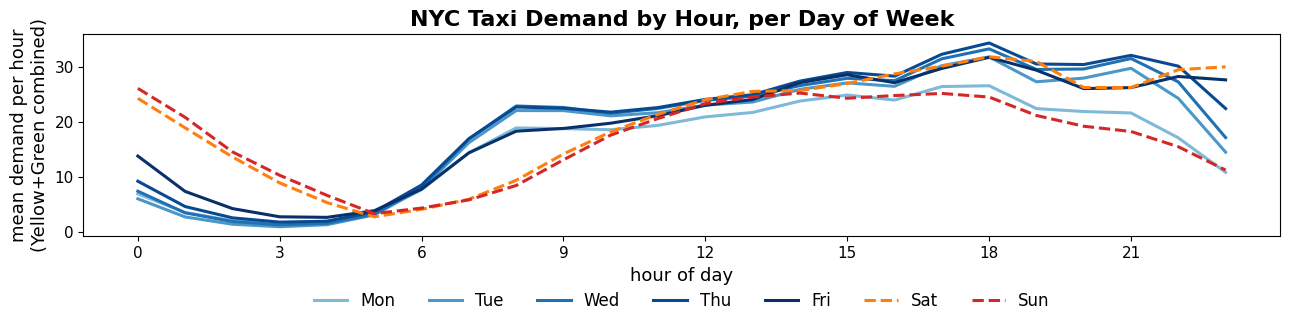

Saved /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final/reports/figures/hourly_by_day_of_week_grouped.png


In [7]:
dow_order = [2, 3, 4, 5, 6, 7, 1]  # Mon..Sun
weekday_blues = plt.cm.Blues([0.45, 0.6, 0.75, 0.9, 1.0])
weekend_warm = ["#ff7f0e", "#d62728"]
colors_grouped = {
    2: weekday_blues[0], 3: weekday_blues[1], 4: weekday_blues[2],
    5: weekday_blues[3], 6: weekday_blues[4], 7: weekend_warm[0], 1: weekend_warm[1],
}

fig, ax = plt.subplots(figsize=(13, 3.5))
for d in dow_order:
    sub = by_day_hour[by_day_hour["day_of_week"] == d].sort_values("hour_of_day")
    style = "--" if d in (1, 7) else "-"
    ax.plot(sub["hour_of_day"], sub["pickup_count"], style, color=colors_grouped[d],
            label=DOW_LABELS[d], linewidth=2.2)
ax.set_xlabel("hour of day", fontsize=13)
ax.set_ylabel("mean demand per hour\n(Yellow+Green combined)", fontsize=13)
ax.set_title("NYC Taxi Demand by Hour, per Day of Week", fontsize=16, fontweight="bold")
ax.set_xticks(range(0, 24, 3))
ax.tick_params(axis="both", labelsize=11)
ax.legend(ncol=7, loc="upper center", bbox_to_anchor=(0.5, -0.2), frameon=False, fontsize=12)
fig.tight_layout()

out_path = FIGURES_DIR / "hourly_by_day_of_week_grouped.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## 4. Section 3.3 — weather and event relationships

How mean demand varies with temperature and with the number of concurrent permitted
events.

In [8]:
df4 = processed_df[["pickup_count", "tmpf", "event_count"]]

temp = df4.dropna(subset=["tmpf"]).copy()
temp["tmpc"] = (temp["tmpf"] - 32) * 5 / 9
bins = list(range(-20, 46, 5))
temp["temp_bin"] = pd.cut(temp["tmpc"], bins=bins, right=False)
by_temp = temp.groupby("temp_bin", observed=True)["pickup_count"].mean()

event_bins = pd.cut(
    df4["event_count"], bins=[-0.5, 0.5, 1.5, 2.5, 5.5, df4["event_count"].max()],
    labels=["0", "1", "2", "3-5", "6+"],
)
event_demand = df4.groupby(event_bins, observed=True)["pickup_count"].mean()

print("Section 3.3 -- demand by temperature bin (\u00b0C)")
print(by_temp)
print("\nSection 3.3 -- demand by event count bin")
print(event_demand)

Section 3.3 -- demand by temperature bin (°C)
temp_bin
[-15, -10)     8.839163
[-10, -5)      8.915909
[-5, 0)        8.244935
[0, 5)         8.794268
[5, 10)        9.264170
[10, 15)       9.329566
[15, 20)       9.337732
[20, 25)       9.080597
[25, 30)      10.127781
[30, 35)      12.117858
[35, 40)      15.948035
Name: pickup_count, dtype: float64

Section 3.3 -- demand by event count bin
event_count
0       7.177920
1      15.758217
2      15.037151
3-5    12.361272
6+     15.148913
Name: pickup_count, dtype: float64


### Figure 4 — demand vs. weather and event context

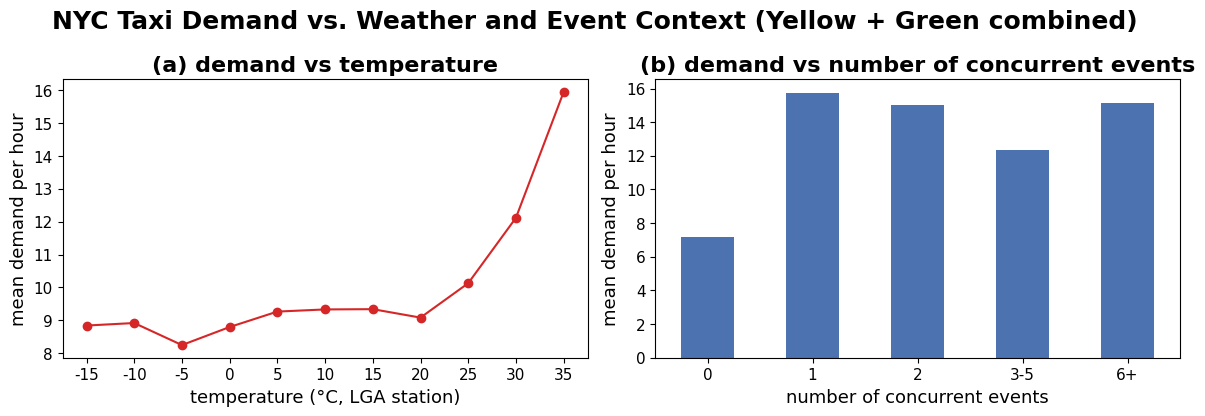

Saved /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final/reports/figures/weather_and_events.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
labels = [f"{int(iv.left)}" for iv in by_temp.index]
ax.plot(labels, by_temp.values, marker="o", color="#d62728")
ax.set_xlabel("temperature (°C, LGA station)", fontsize=13)
ax.set_ylabel("mean demand per hour", fontsize=13)
ax.set_title("(a) demand vs temperature", fontsize=16, fontweight="bold")
ax.tick_params(axis="both", labelsize=11)
ax.tick_params(axis="x", rotation=0)

ax = axes[1]
# Matches Figure 2a's histogram colour (#4c72b0) for consistency across the report,
# replacing the previous aqua/cyan (#17becf) which didn't match anything else.
event_demand.plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_xlabel("number of concurrent events", fontsize=13)
ax.set_ylabel("mean demand per hour", fontsize=13)
ax.set_title("(b) demand vs number of concurrent events", fontsize=16, fontweight="bold")
ax.tick_params(axis="both", labelsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

fig.suptitle(
    "NYC Taxi Demand vs. Weather and Event Context (Yellow + Green combined)",
    y=0.98, fontsize=18, fontweight="bold",
)
fig.tight_layout()

out_path = FIGURES_DIR / "weather_and_events.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Notes

- All figures read directly from `data/processed/pickups_zone_hour.parquet` (pandas, no
  Spark session needed at this grain/size).
- Section 2.3.2's baseline-pivot numbers and Figure 1 were computed in notebook `04`
  (where the baseline itself gets built), not recomputed here.
- Monday-vs-Thursday and weekend-vs-weekday-midnight numbers computed above are EDA only
  (Section 3.2) -- they do not feed any Recommendation. An earlier version of
  Recommendation 2 cited them directly; that recommendation has since been replaced with
  a severe-weather reliability finding (Section 6.2, notebook `08`), which does not use
  these numbers at all.